# CIFAR10 ResNet 실습



# CIFAR10 이미지 분류 실험

본 노트북은 CIFAR10 데이터셋을 이용하여 ResNet 기반 이미지 분류 모델을 학습하고 성능을 평가하는 실험이다.  
CIFAR10은 10개 클래스로 이루어진 32×32 크기의 RGB 이미지 데이터셋이며,  
훈련 데이터 50,000장과 테스트 데이터 10,000장으로 구성된다.

모델은 ResNet 구조를 바탕으로 직접 구현하였으며, `BasicBlock`을 사용하는  
`ResNet(BasicBlock, [2,2,2,2], num_classes=10)` 형태를 사용하였다.  
다만 CIFAR10은 이미지 크기가 작기 때문에, ImageNet용 ResNet의 초기 `7×7 convolution`과 `maxpool` 대신  
`3×3 convolution`과 `Identity`를 사용하여 CIFAR10에 맞게 수정하였다.

학습에는 Adam optimizer와 CrossEntropyLoss를 사용하였고,  
학습 과정에서 train/test loss와 accuracy를 기록하여 모델의 성능 변화를 분석하였다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision

from torch import Tensor
from typing import Optional, Callable, Type, Union
from torchvision import transforms
from torch.utils.data import DataLoader


In [ ]:
batch_size = 128
num_epochs = 5
learning_rate = 0.001


## 1. CIFAR10 불러오기


In [ ]:
train_set_raw = torchvision.datasets.CIFAR10(
    root='./cifar10', train=True, download=True, transform=transforms.ToTensor()
)

test_set_raw = torchvision.datasets.CIFAR10(
    root='./cifar10', train=False, download=True, transform=transforms.ToTensor()
)

print(len(train_set_raw), len(test_set_raw))


50000 10000
50000 10000


## 2. 채널별 평균과 표준편차 계산


In [ ]:
train_meanRGB = np.array([np.mean(x.numpy(), axis=(1, 2)) for x, _ in train_set_raw])
train_stdRGB = np.array([np.std(x.numpy(), axis=(1, 2)) for x, _ in train_set_raw])

meanRGB = train_meanRGB.mean(axis=0)
stdRGB = train_stdRGB.mean(axis=0)

print('meanRGB =', meanRGB)
print('stdRGB =', stdRGB)


meanRGB = [0.4914009  0.48215896 0.4465308 ]
stdRGB = [0.20220287 0.19931626 0.20086344]
meanRGB = [0.4914009  0.48215896 0.4465308 ]
stdRGB = [0.20220287 0.19931626 0.20086344]


## 3. 정규화 transform 적용


In [ ]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=meanRGB, std=stdRGB)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=meanRGB, std=stdRGB)
])

train_set = torchvision.datasets.CIFAR10(
    root='./cifar10', train=True, download=True, transform=transform_train
)

test_set = torchvision.datasets.CIFAR10(
    root='./cifar10', train=False, download=True, transform=transform_test
)


## 4. DataLoader 생성


In [ ]:
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)


torch.Size([128, 3, 32, 32])
torch.Size([128])
torch.Size([128, 3, 32, 32])
torch.Size([128])


## 5. ResNet 구성 요소 정의


In [ ]:
def conv3x3(in_planes: int, out_planes: int, stride: int = 1, groups: int = 1, dilation: int = 1) -> nn.Conv2d:
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )


def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion: int = 1

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError('BasicBlock only supports groups=1 and base_width=64')
        if dilation > 1:
            raise NotImplementedError('Dilation > 1 not supported in BasicBlock')

        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion: int = 4

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        downsample: Optional[nn.Module] = None,
        groups: int = 1,
        base_width: int = 64,
        dilation: int = 1,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d

        width = int(planes * (base_width / 64.0)) * groups

        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x: Tensor) -> Tensor:
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):
    def __init__(
        self,
        block: Type[Union[BasicBlock, Bottleneck]],
        layers,
        num_classes: int = 10,
        zero_init_residual: bool = False,
        groups: int = 1,
        width_per_group: int = 64,
        replace_stride_with_dilation=None,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()

        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1

        if replace_stride_with_dilation is None:
            replace_stride_with_dilation = [False, False, False]

        self.groups = groups
        self.base_width = width_per_group

        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.Identity()

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2, dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2, dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2, dilate=replace_stride_with_dilation[2])

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(
        self,
        block: Type[Union[BasicBlock, Bottleneck]],
        planes: int,
        blocks: int,
        stride: int = 1,
        dilate: bool = False,
    ) -> nn.Sequential:
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation

        if dilate:
            self.dilation *= stride
            stride = 1

        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(
            block(
                self.inplanes,
                planes,
                stride,
                downsample,
                self.groups,
                self.base_width,
                previous_dilation,
                norm_layer,
            )
        )

        self.inplanes = planes * block.expansion

        for _ in range(1, blocks):
            layers.append(
                block(
                    self.inplanes,
                    planes,
                    groups=self.groups,
                    base_width=self.base_width,
                    dilation=self.dilation,
                    norm_layer=norm_layer,
                )
            )

        return nn.Sequential(*layers)

    def _forward_impl(self, x: Tensor) -> Tensor:
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def forward(self, x: Tensor) -> Tensor:
        return self._forward_impl(x)


## 6. 모델 생성


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet(BasicBlock, [2, 2, 2, 2], num_classes=10).to(device)
print(device)
print(model)


cuda
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 

## 7. loss, optimizer 정의


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


## 8. train / evaluate 함수


In [ ]:
def train(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    return train_loss, train_acc


def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss = running_loss / len(test_loader)
    test_acc = 100 * correct / total
    return test_loss, test_acc


## 9. 학습 실행


In [ ]:
train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1} start")

    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f}, Test  Acc: {test_acc:.2f}%")

print(f"Final Test Accuracy: {test_accs[-1]:.2f}%")

Epoch 1 start
Epoch [1/5]
Train Loss: 1.3391, Train Acc: 51.25%
Test  Loss: 1.0401, Test  Acc: 62.51%
Epoch 2 start
Epoch [2/5]
Train Loss: 0.8212, Train Acc: 70.90%
Test  Loss: 0.8560, Test  Acc: 71.44%
Epoch 3 start
Epoch [3/5]
Train Loss: 0.5964, Train Acc: 79.21%
Test  Loss: 0.6514, Test  Acc: 77.18%
Epoch 4 start
Epoch [4/5]
Train Loss: 0.4560, Train Acc: 84.10%
Test  Loss: 0.5243, Test  Acc: 81.81%
Epoch 5 start
Epoch [5/5]
Train Loss: 0.3559, Train Acc: 87.44%
Test  Loss: 0.5870, Test  Acc: 80.26%
Final Test Accuracy: 80.26%
Epoch 1 start
Epoch [1/5]
Train Loss: 1.3541, Train Acc: 50.64%
Test  Loss: 1.1714, Test  Acc: 58.16%
Epoch 2 start
Epoch [2/5]
Train Loss: 0.8390, Train Acc: 69.92%
Test  Loss: 0.8301, Test  Acc: 71.18%
Epoch 3 start
Epoch [3/5]
Train Loss: 0.6181, Train Acc: 78.22%
Test  Loss: 0.6799, Test  Acc: 76.34%
Epoch 4 start
Epoch [4/5]
Train Loss: 0.4846, Train Acc: 83.02%
Test  Loss: 0.5901, Test  Acc: 80.07%
Epoch 5 start
Epoch [5/5]
Train Loss: 0.3815, Train Ac

## 10. 결과 시각화


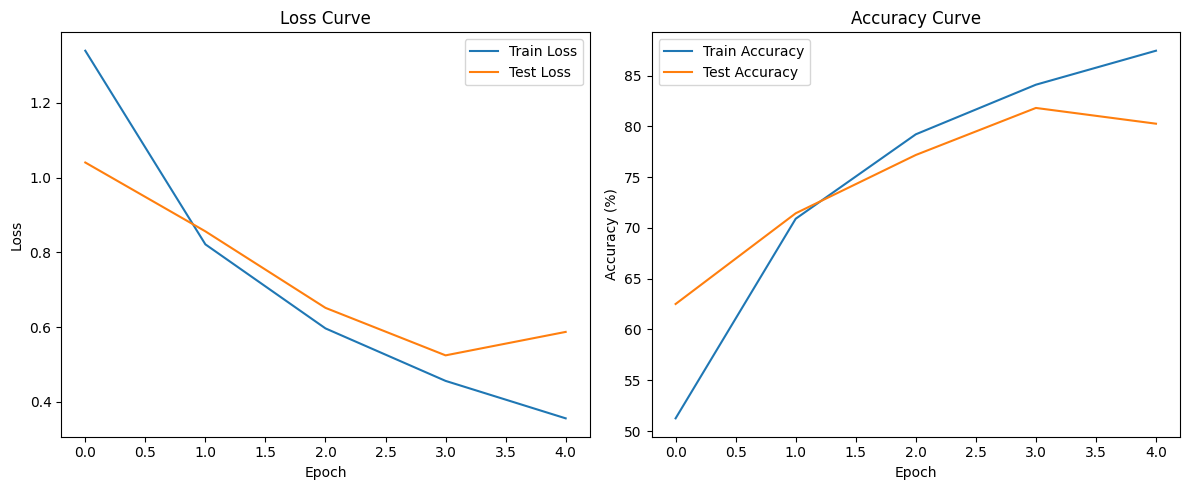

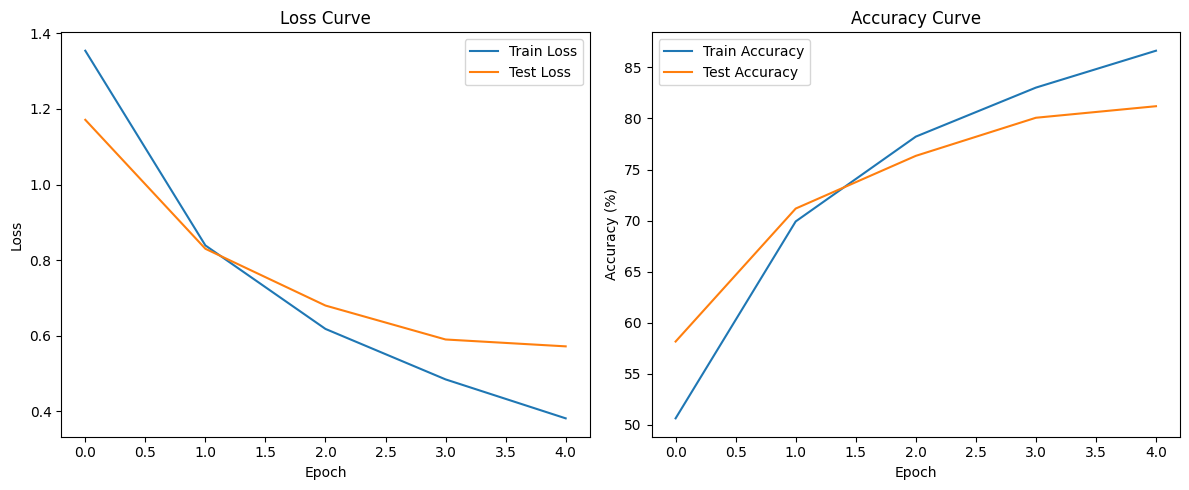

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()
